# Complete the details below/*Vul die ontbrekende inligting hieronder in*:

## Name/*Naam*: Joseph Mudge


### Student Number/*Studente Nommer*: 27905896

In [7]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import HTML

from sklearn.linear_model import LogisticRegression as logis
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import different modules for using with the notebook
from IPython.display import display
from IPython.display import Image

# Generate training data/*Genereer afrigtingsdata*

0
1
2


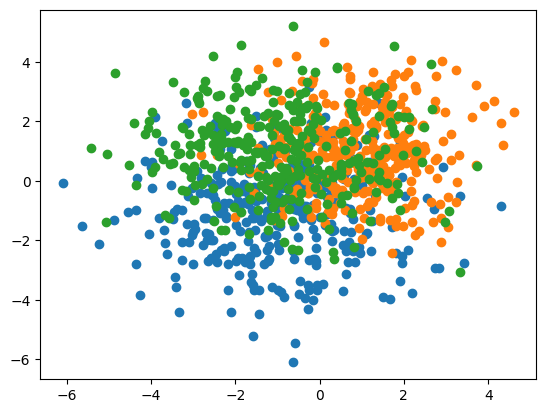

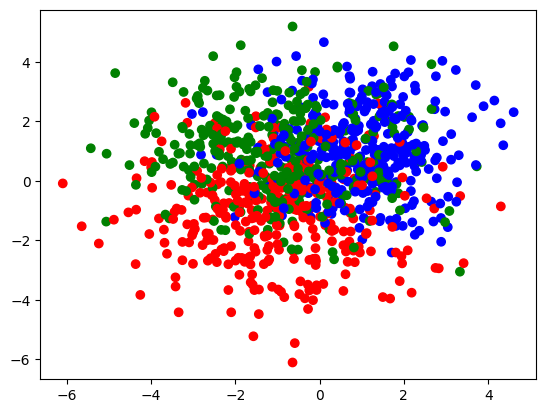

In [3]:
# Training data - three randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2+1, size = N)
# Mean of each cluster
means = np.array([[-1, 1, -1], [-1, 1, 1],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 3)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])
# Plot the Data
# Version 1
for i in range(3):
    index = y == i
    print(i)
    x_plt = X[0,index]
    y_plt = X[1,index]
    plt.plot(x_plt, y_plt, 'o') 
plt.show()

# Version 2 (the better one by Steve)
colours = np.array(["red", "blue", "green"])
plt.scatter(X[0,:], X[1,:], c=colours[y])

#### Display the data that you generated (the result should be similar to the image below)/*Vertoon nou die gegenireerde data (die resultaat moet soortgelyk wees aan die onderstaande beeld)*:

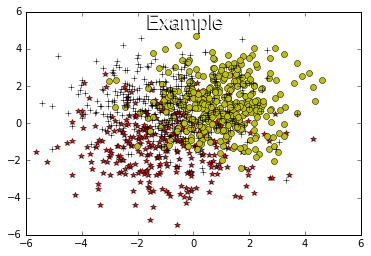

In [5]:
display(Image(filename='./images/wm_dat1.png'))

# Fit the training data to the scikit-learn softmax classifier/*Rig nou 'n softmax klassifiseerder af met die gegenereerde data*

The image above shows that there is considerable overlap between the classes. Use your trained classifier to assign all the training data to different classes.

*Die beeld hierbo wys dat die data van die verskillende klasse geweldig ourvleul. Gebruik nou jou afgerigte klassifiseerder om etikette aan al die datapunte toe te ken.*

**Print the confusion matrix and also plot it, to get something like the image below:**

**_Druk en stip nou die verwarringsmatriks. Jy behoort 'n beeld soortgelyk te kry as die een hieronder:_**

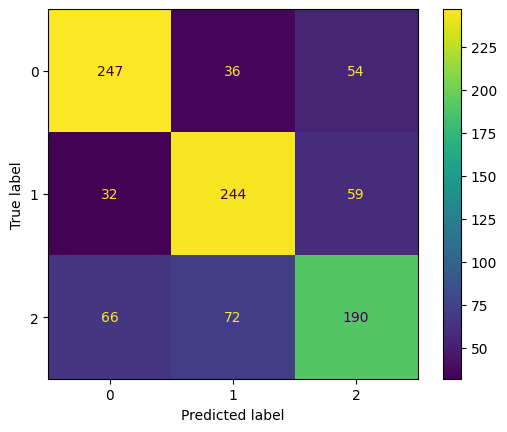

In [4]:
clf = logis(solver='lbfgs')
clf.fit(X.T, y)
y_preds = clf.predict(X.T)
conf_mat = confusion_matrix(y, y_preds)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat)
conf_mat_disp.plot()
plt.show()

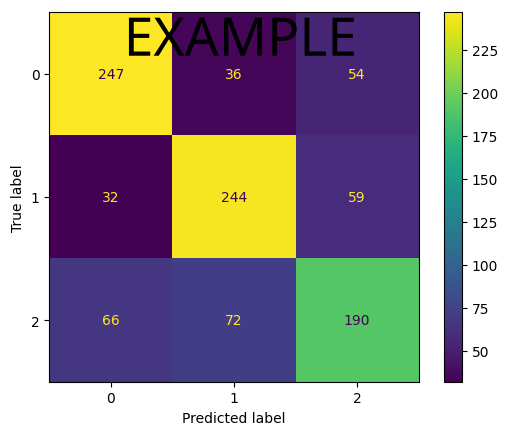

In [47]:
display(Image(filename='./images/wm_confusion.png'))

**Now plot the different classes as predicted by your system. You should get something like:** 

**_Stip nou die verskillende klasse (soos deur jou sisteem voorspel word). Jy behoort die volgende te kry:_** 

**Can you tell from the graph that this is a *linear* classifier?**

**_Kan jy van die grafiek af aflei dat die 'n lineere klassifiseerder is?_**

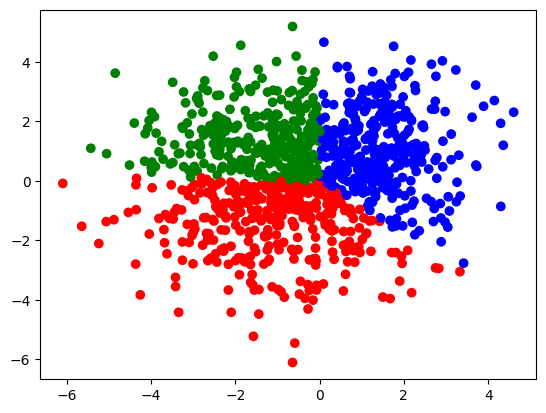

In [5]:
colours = np.array(["red", "blue", "green"])
plt.scatter(X[0,:],X[1,:] , c=colours[y_preds])
plt.show()

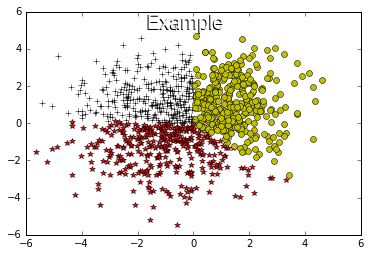

In [7]:
display(Image(filename='./images/wm_dat2.png'))

# Implement a Naive Bayes Classifier/_Implementeer 'n Naiewe Bayes Klassifieerder_

Implement your own Naive Bayes Classifier (from first principles). Train it using the exact same data you used for the previous question (write it in a seperate python file which you can import into the notebook). Implement it in a generic way, i.e. it should be able to work on $d$ dimensional data and it should not be limited to a certain amount of classes.

_Implementeer nou jou eie Naiewe Bayes Klassifiseerder (vanaf eerste beginsels). Rig dit af met presies dieselfde data wat jy gebruik het om jou vorige vraag te antwoord (implementeer die klassifiseerder in 'n aparte Python leer; voer dan die leer in hierdie notebook in). Maak jou implementasie so generies as moontlik, m.a.w. dit moet werk op $d$-dimensionele data en dit moet ook nie beperk wees tot 'n sekere aantal klasse nie._ 

Use your trained classifier to assign all the training data to different classes. _Gebruik nou jou implementasie om al die data aan verskillende klasse te allokeer._

**Print the confusion matrix and also plot it, to get something like the image below**

**_Druk en stip nou die verwarringsmatriks. Jy behoort 'n beeld soortgelyk te kry as die een hieronder_**

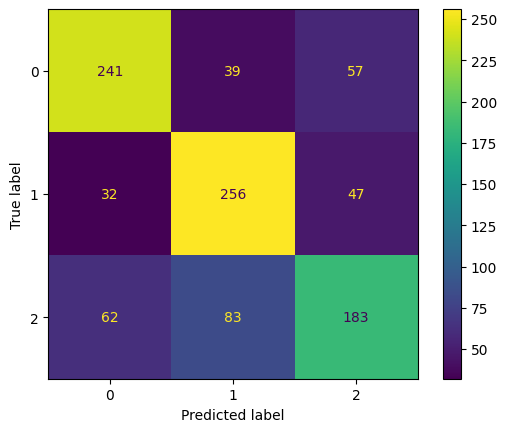

In [8]:
from naive_bayes import * 
X_train = X.T
y_train = y

clf = GaussianNaiveBayes()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_train)

conf_mat = confusion_matrix(y_train, y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat)

conf_mat_disp.plot()
plt.show()

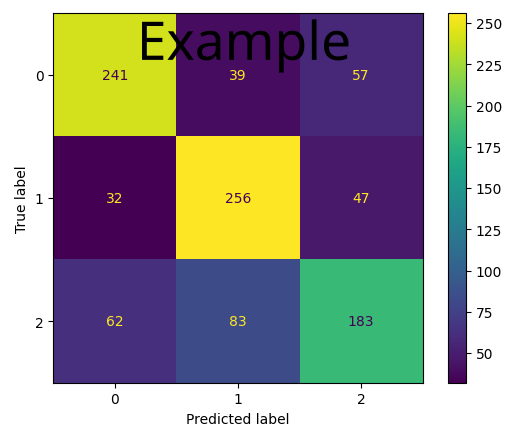

In [24]:
display(Image(filename='./images/conf_mat_bayes.png'))

**Now plot the different classes as predicted by your system. You should get something like:**

**_Stip nou die verskillende klasse (soos deur jou sisteem voorspel word). Jy behoort die volgende te kry:_** 

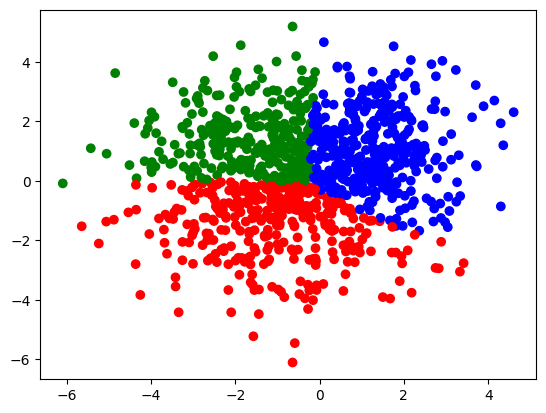

In [9]:
colours = np.array(["red", "blue", "green"])
plt.scatter(X[0,:],X[1,:] , c=colours[y_pred])
plt.show()

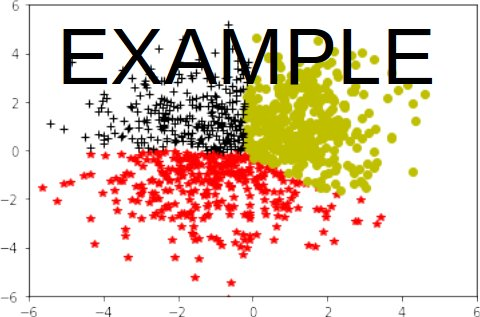

In [9]:
display(Image(filename='./images/predict_bayes.jpg'))

# Chapter 4 Study Notes: Probabilistic Generative Models

## 4.2 Probabilistic Generative Models

### Core Concept
Probabilistic generative models require a class-conditional model $p(x|\mathcal{C}_j)$ and prior class probabilities $P(\mathcal{C}_j)$ to compute the posterior probability $P(\mathcal{C}_j|x)$ via Bayes' theorem. Common choices for class-conditional models include Gaussian or mixture of Gaussian distributions.

### Two-Class Problem
For two classes, the posterior probability is expressed using the logistic sigmoid function:
$$P(\mathcal{C}_1|x) = \frac{p(x|\mathcal{C}_1)P(\mathcal{C}_1)}{p(x|\mathcal{C}_1)P(\mathcal{C}_1) + p(x|\mathcal{C}_2)P(\mathcal{C}_2)} = \frac{1}{1 + \exp(-a(x))} = \sigma(a(x))$$


[Image of logistic sigmoid function graph]


* **Log Posterior Odds ($a(x)$):** $$a(x) = \ln \frac{p(x|\mathcal{C}_1)P(\mathcal{C}_1)}{p(x|\mathcal{C}_2)P(\mathcal{C}_2)}$$
* **Classification Rule:** An observation $x$ is assigned to $\mathcal{C}_1$ if the odds ratio $\frac{p(x|\mathcal{C}_1)P(\mathcal{C}_1)}{p(x|\mathcal{C}_2)P(\mathcal{C}_2)} > 1$; otherwise, it is assigned to $\mathcal{C}_2$.

### Multi-Class Problem ($k$ classes)
For $k$ classes, the posterior probability uses the normalized softmax function:
$$P(\mathcal{C}_n|x) = \frac{\exp(a_n(x))}{\sum_{j=1}^k \exp(a_j(x))}$$
where $a_j(x) = \ln p(x|\mathcal{C}_j) + \ln P(\mathcal{C}_j)$. 

The softmax function smoothly highlights the most probable class; if $a_n \gg a_j$ for $j \neq n$, then $P(\mathcal{C}_n|x) \approx 1$.

---

## 4.2.1 Gaussian Class-Conditional PDFs

### Shared Covariance Matrix
When assuming Gaussian class-conditional densities that share the same covariance matrix ($\Sigma$) but have different means ($\mu_j$), the model simplifies significantly.

* **Two-Class Linear Boundaries:**
    The log-odds $a(x)$ becomes a linear function: $a(x) = w^T x + w_0$.
    $$P(\mathcal{C}_1|x) = \sigma(w^T x + w_0)$$
    Where the parameters are derived as:
    $$w = \Sigma^{-1}(\mu_1 - \mu_2)$$
    $$w_0 = -\frac{1}{2}\mu_1^T \Sigma^{-1}\mu_1 + \frac{1}{2}\mu_2^T \Sigma^{-1}\mu_2 + \ln \frac{P(\mathcal{C}_1)}{P(\mathcal{C}_2)}$$
* **Key Properties:**
    1.  Prior probabilities only affect the bias term $w_0$.
    2.  Quadratic terms in the Gaussian equations cancel out due to the shared covariance, resulting in a **linear classifier**. The decision boundary is defined by $w^T x + w_0 = 0$.
    3.  **Parameter Reduction:** Instead of estimating $2d + \frac{1}{2}d(d+1)$ parameters, the linear formulation directly reduces this to $d+1$ parameters (this realization forms the basis for discriminative models like logistic regression).

* **Multi-Class ($k$ classes) Shared Covariance:**
    Results in linear decision boundaries between classes using $a_j(x) = w_j^T x + w_{j0}$.

### Non-Shared Covariance Matrices
If the Gaussian distributions do not share a covariance matrix, the quadratic terms no longer cancel, resulting in **quadratic decision boundaries**.


---

## 4.2.2 Maximum Likelihood Solution

To determine the parameters of the class-conditional densities and priors, Maximum Likelihood Estimation (MLE) is applied to a fully observed dataset.

* **Prior Probabilities:** Estimated as the fraction of data points in each class:
    $$\pi = \frac{N_1}{N}$$
* **Means ($\mu_1, \mu_2$):** Estimated using the target labels ($y_n \in \{0, 1\}$):
    $$\mu_1 = \frac{1}{N_1} \sum_{n=1}^N y_n x_n \quad \text{and} \quad \mu_2 = \frac{1}{N_2} \sum_{n=1}^N (1 - y_n) x_n$$
* **Covariances ($\Sigma_1, \Sigma_2$):** Calculated exclusively using the subset of data known to belong to that specific class:
    $$\Sigma_1 = \frac{1}{N_1} \sum_{n \in \mathcal{C}_1} (x_n - \mu_1)(x_n - \mu_1)^T$$

---

## 4.2.3 Naive Bayes Classifier

### The Dimensionality Problem
* A $k$-class model with **full, non-shared covariance matrices** requires estimating $\frac{1}{2}kd(d+3)$ parameters, which is computationally unwieldy for high dimensions ($d$).
* A model with a **shared full covariance matrix** reduces this to $kd + \frac{1}{2}d(d+1)$, but may lack the flexibility to accurately describe each class.

### The Naive Bayes Assumption
The Naive Bayes model strikes a computational balance by assuming that all attributes (features) are conditionally independent given the class:
$$p(x|\mathcal{C}) = \prod_{n=1}^d p(x_n|\mathcal{C})$$


* **Impact:** This assumption forces the covariance matrix for each class to be strictly **diagonal**.
* **Parameter Reduction:** The total parameter count drops dramatically to $2kd$, making it highly efficient for large-dimensional spaces.

### Classification Rule
Applying Bayes' theorem and removing the constant denominator, the naive classification rule assigns an observation to the class that maximizes:
$$\mathcal{C}^* = \arg\max_{\mathcal{C}_j} P(\mathcal{C}_j) \prod_{n=1}^d p(x_n|\mathcal{C}_j)$$

### Maximum Likelihood Estimates for Naive Bayes (Gaussian)
Assuming Gaussian distributions, the ML estimates for a given class $\mathcal{C}_j$ and feature $n$ are calculated independently:
* Prior: $P(\mathcal{C}_j) = \frac{N_j}{N}$
* Feature Mean: $\mu_{nj} = \frac{1}{N_j} \sum_{x \in \mathcal{C}_j} x_{nj}$
* Feature Variance: $\sigma_{nj}^2 = \frac{1}{N_j} \sum_{x \in \mathcal{C}_j} (x_{nj} - \mu_{nj})^2$

# Implement a Logistic Regression Classifier/_Implementeer 'n Logistiese Regessie Klassifiseerder_

Implement your own Logistic Regression classifier (from first principles). It should be generic and be able to work on $d$ dimensional data (and two classes). Please make your implementation as modular as possible, having a seperate function for the Hessian and the gradient vector (write it in a seperate python file which you can import into the notebook). A regularization term based on a Gaussian prior (with zero mean and covariance matrix $\lambda\mathbf{I}$) must be included.  Optionally, a bias term also needs to be incorporated into your classifier - this can be implemented by augmenting the training dataset with an additional all-one feature.

_Implementeer jou eie Logistiese Regressie Klassifiseerder (vanaf eerste beginsels). Jou implementasie moet generies wees en moet as invoer $d$-dimensionele data as toevoer kan ontvang (vir twee klasse). Maak jou implementasie so moduler as moontlik. Gebruik aparte funksies vir die Hessian en die gradient vektor (skryf jou klassifiseerder in 'n aparte Python leer wat jy dan in die notebook kan invoer). Jy moet ook regularisering implementeer (aanvaar 'n Normale prior (met 'n gemiddeld van nul en 'n kovariansie matriks wat gelyk is aan $\lambda\mathbf{I}$). Die opsie moet ook beskikbaar wees om 'n partydigheids term te kan inkorporeer as dit nodig sou wees - dit word in praktyk bewerkstelling deur 'n ekstra kenmerk kolom tot jou datastel te voeg wat slegs uit ene bestaan._

**Now train your classifier using the following data/_Rig nou jou klassifiseerder af deur gebruik te maak van die volgende data_**. Assume/Aanvaar: $\lambda = 10^{-8}$.

In [10]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
# Mean of each cluster
means = np.array([[-1, 1], [-1, 1],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

**Use your trained classifier to assign all the training data to different classes.**

**_Gebruik nou jou implementasie om al die data aan verskillende klasse te allokeer_**

**Print the confusion matrix and also plot it, to get something like the image below:** 

**_Druk en stip nou die verwarringsmatriks. Jy behoort 'n beeld soortgelyk te kry as die een hieronder_**

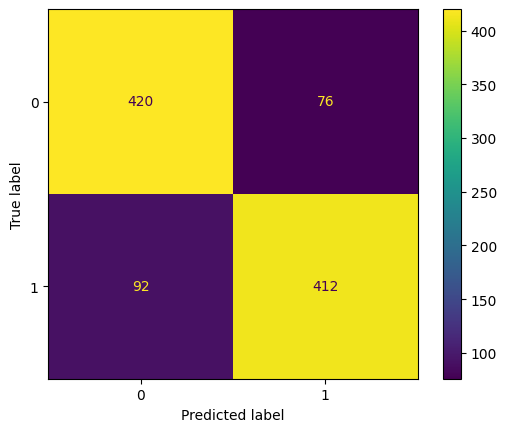

In [15]:
from logistic_regression import *

clf = BayesianLogisticRegression()

clf.fit(X.T, y)

y_pred = clf.predict(X.T)

conf_mat = confusion_matrix(y, y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat)
conf_mat_disp.plot()
plt.show()

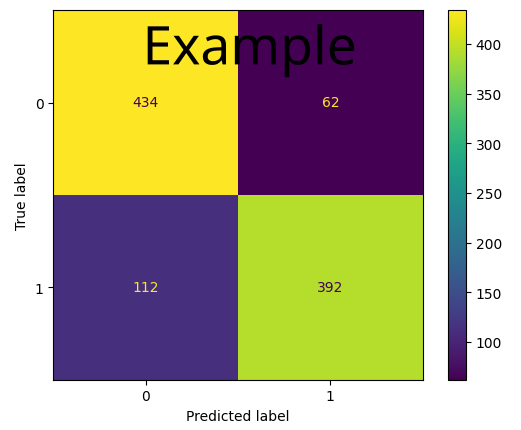

In [11]:
display(Image(filename='./images/conf_mat_logreg2.png'))

**Now plot the different classes as predicted by your system. Add your decision boundary to the same plot. You should get something like:**

**_Stip nou die verskillende klasse (soos deur jou sisteem voorspel word). Voeg ook jou skeidingsgrens by. Jy behoort die volgende te kry:_** 

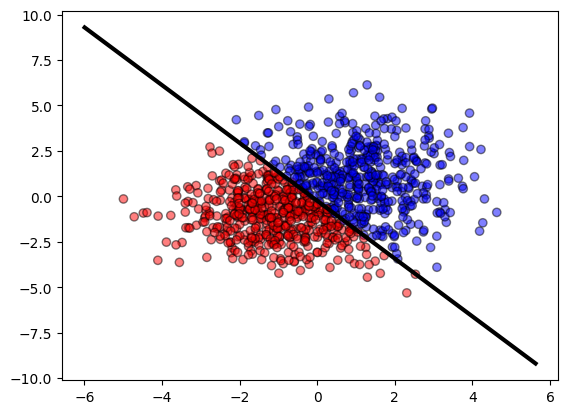

In [14]:
colours = np.array(["red", "blue"])
plt.scatter(X[0, :], X[1, :], c=colours[y_pred], alpha=0.5, edgecolors='k')
# Calculate decision boundary coordinates
# Equation: w0 + w1*x + w2*y = 0 -> y = -(w0 + w1*x) / w2
w = clf.w
x_boundary = np.array([np.min(X[0, :]) - 1, np.max(X[0, :]) + 1])
y_boundary = -(w[0] + w[1] * x_boundary) / w[2]
plt.plot(x_boundary, y_boundary, color="black", linestyle="-", linewidth=3)
plt.show()

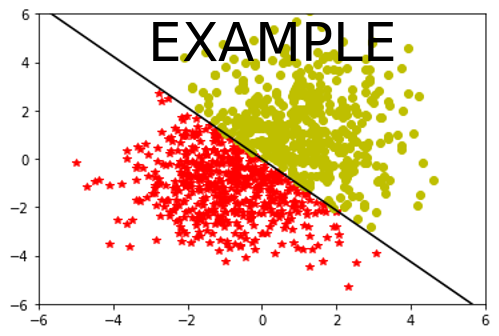

In [13]:
display(Image(filename='./images/predict_logreg2.png'))

# Chapter 4 Study Notes: Probabilistic Discriminative Models

## 4.3.1 Logistic Regression

### Core Concept
Logistic regression is a discriminative probabilistic model that skips the intermediate step of modeling class-conditional densities. It directly models the posterior probability of a class using a linear equation mapped through a logistic sigmoid function.

### Mathematical Formulation
By combining the bias parameter $w_0$ and the feature variables into unified vectors $w$ and $x$, the probability that an observation belongs to class $\mathcal{C}_1$ is defined as:
$$P(\mathcal{C}_1|x, w) = \sigma(w^T x)$$
where $\sigma$ represents the logistic sigmoid function. The probability for the opposing class is the complement: $P(\mathcal{C}_2|x, w) = 1 - P(\mathcal{C}_1|x, w)$.

The decision boundary dictates where the model is equally uncertain between the two classes ($P(\mathcal{C}_1|x, w) = P(\mathcal{C}_2|x, w)$). This simplifies to the linear hyperplane:
$$w^T x = 0$$

### Optimization and the Negative Log-Likelihood
To find the optimal weights ($w$), the model relies on a fully observed training dataset where labels $y_n$ are binary ($0$ or $1$). 
The joint probability is modeled as a product of Bernoulli distributions. For numerical stability, optimization minimizes the negative log-likelihood:
$$E(w) = -\sum_{n=1}^N \{y_n \ln \sigma(w^T x_n) + (1 - y_n) \ln(1 - \sigma(w^T x_n))\}$$

The gradient of this error function dictates the weight updates:
$$\nabla E(w) = \sum_{n=1}^N (\sigma(w^T x_n) - y_n) x_n$$
Setting this gradient to zero produces a non-linear system requiring numerical gradient-based techniques (e.g., Newton-Raphson).

### Model Intuition and the Overfitting Problem
* **Boundary-Driven Learning:** For a point far from the boundary and correctly classified, the prediction approaches absolute certainty ($\sigma(w^T x_n) \approx 1$). The error multiplier approaches $0$, meaning highly confident points exert almost no influence on gradient updates.
* **Specialization Risk:** The boundary is dictated almost entirely by ambiguous, borderline points. Increasing model flexibility risks over-adapting to these specific points.
* **Weight Inflation:** The optimizer can artificially increase confidence by scaling up the magnitude of $w$ ($w^T x \to \infty$) without changing the boundary's geometric position.
* **Regularization:** To prevent parameter inflation and overfitting, discriminative models must be constrained, typically by adding a regularization penalty term.

---

## 4.3.2 A Bayesian Approach

### Core Concept
The Bayesian approach treats model weights ($w$) as random variables. The posterior class probability is determined by marginalizing over the weight parameters:
$$P(\mathcal{C}_1|x, \mathcal{D}) = \int P(\mathcal{C}_1|w, x)p(w|\mathcal{D})dw$$

### Maximum A Posteriori (MAP) Approximation
Evaluating the full integral requires advanced numerical methods (e.g., MCMC). In practice, it is approximated using the Maximum A Posteriori (MAP) estimate. If the posterior density $p(w|\mathcal{D})$ is sharply peaked at its maximum ($w^*$), the integral simplifies to $P(\mathcal{C}_1|w^*, x)$.

### Mathematical Formulation of MAP
The MAP estimate minimizes the negative logarithm of the posterior density function: $E(w) = -\ln p(w|\mathcal{D})$. Applying Bayes' theorem:
$$w^* = \arg\min_w (-\ln p(\mathcal{D}|w) - \ln p(w))$$

### Prior Selection and Regularization
Using an isotropic normal distribution for the prior $p(w) = \mathcal{N}(w|0, \lambda I)$ yields:
$$w^* = \arg\min_w \left( -\ln p(\mathcal{D}|w) + \frac{1}{2\lambda}w^T w \right)$$
The term $\frac{1}{2\lambda}w^T w$ acts as a regularization penalty, emerging naturally from the prior. The hyperparameter $\lambda$ requires a validation dataset for tuning.

---

## 4.3.3 Newton's Method for Minimizing the Negative Log-Posterior

### Objective and Gradient
The objective is to find the MAP estimate $w^*$ by minimizing the negative log-posterior $\ell(w)$:
$$\ell(w) = -\sum_{n=1}^N \{y_n \ln \sigma(w^T x_n) + (1 - y_n) \ln(1 - \sigma(w^T x_n))\} + \frac{1}{2\lambda}w^T w + \text{const}$$

Setting the gradient to zero creates a nonlinear system:
$$\nabla \ell(w) = -\sum_{n=1}^N (y_n - \sigma(w^T x_n))x_n + \frac{1}{\lambda}w = 0$$

### Newton's Method Iteration
Newton's method iteratively updates weights using the Hessian matrix $H(w^{(k)})$:
$$H(w^{(k)}) (w^{(k+1)} - w^{(k)}) = -\nabla \ell(w^{(k)})$$

### The Hessian Matrix and Convergence
The Hessian matrix captures second-order partial derivatives:
$$H(w) = \sum_{n=1}^N \sigma(w^T x_n)(1 - \sigma(w^T x_n))x_n x_n^T + \frac{1}{\lambda}I$$
To ensure convergence to a global minimum, $H(w)$ must be positive definite ($z^T H(w) z > 0$ for all $z \neq 0$). Because $0 < \sigma_n < 1$, the quadratic form is strictly positive. This universal positive definiteness guarantees a single global minimum, ensuring fast convergence regardless of initialization.

---

## 4.3.4 Multi-Class Logistic Regression

### Class Probabilities and Weights
For $k$ classes, $k$ distinct weight vectors ($w_i$) are compiled into a matrix $W$. The posterior probability for class $\mathcal{C}_i$ uses the softmax function:
$$P(\mathcal{C}_i|x, W) = \frac{\exp(w_i^T x)}{\sum_{j=1}^k \exp(w_j^T x)}$$

### Data Encoding and Joint Likelihood
Target classifications $t_n$ use a 1-of-$k$ coding scheme. The joint distribution for the dataset assumes a multinoulli distribution:
$$p(X, T|W) = p(X) \prod_{n=1}^N \prod_{j=1}^k P(\mathcal{C}_j|x_n, W)^{t_{nj}}$$

### Objective Function and Gradient
The negative log-likelihood function $\ell(W)$ is:
$$\ell(W) = -\ln p(X) - \sum_{n=1}^N \sum_{j=1}^k t_{nj} \left[ w_j^T x_n - \ln \left( \sum_{i=1}^k \exp(w_i^T x_n) \right) \right]$$

The gradient with respect to a specific class weight vector $w_p$ is:
$$\nabla_{w_p} \ell(W) = \sum_{n=1}^N \left[ \frac{\exp(w_p^T x_n)}{\sum_{i=1}^k \exp(w_i^T x_n)} - t_{np} \right] x_n$$
Without a closed-form analytical solution, iterative techniques like gradient descent are required.

**Before continuing in the notebook, you will need to install the `lasagne` Python module with "pip3 install --user lasagne"**

**_Jy sal eers die `lasagne` Python module moet installeer (gebruik "pip3 install --user lasagne") voordat jy die res van die notebook sal kan hardloop._**

# Now classify the MNIST digits/_Klassifiseer nou die MNIST syfers_ 

The MNIST database provided in the assignment resources consists of low-resolution (28x28) grayscale images of handwritten digits ($0,1,2,3,4,5,6,7,8,9$). First, you read in a set of training digits and display them interactively to get an idea what they look like. Afterwards, you build and train a softmax classifier using scitkit-image and scikit-learn. You will then classify the digits in the test set and display the results. Finally, you will display the weights as images.

_Die MNIST datastel wat in die werkopdrag hulpbronne verkrygbaar is bestaan uit lae resolusie (28x28) grysskaal beelde van handgeskrewe sysfers ($0,1,2,3,4,5,6,7,8,9$). Ons gaan eers 'n afrigtingsstel inlees en dan dinamies vertoon sodat jy 'n beter idee kan vorm van hoe die datastel lyk. Daarna gaan jy 'n softmax klassifiseerder afrig (gebruik scitkit-image en scikit-learn). Laastens sal ons die syfers in die toetsstel klassifiseer en ook die resultate wat so verkry is vertoon._ 

First load the dataset - for more information about the dataset, see http://yann.lecun.com/exdb/mnist/.

_Laai eers die datastel - vir verdere inligting rakende die datastel: http://yann.lecun.com/exdb/mnist/._

In [38]:
from mnist import load_dataset
X_train, y_train, X_valid, y_valid, X_test, y_test = load_dataset()

## Display the test digits interactively/_Vertoon die syfers dinamies_.

In [19]:
from ipywidgets import interact
def show_digits(k=0):
    """
    Show the first 1000 digits in the training set
    """
    
    plt.imshow(X_train[k][0], cmap=cm.binary)   
    
    plt.show()
    
w = interact(show_digits, k =(0, 1000)) 


interactive(children=(IntSlider(value=0, description='k', max=1000), Output()), _dom_classes=('widget-interact…

## Train the softmax classifier/_Rig die softmax klassifiseerder af_

**Using the training set, build a softmax classifier. Use this classifier to classify the digits in the training set and the test set separately. Print the confusion matrix and also display it as an image for each case to get something like:**

**_Bou 'n softmax klassifiseerder deur gebruik te maak van die afrigtingsstel. Gebruik dan die klassifiseerder om die syfers in die afrigtingsstel asook die toetstel te klassifiseer. Vertoon en stip die verwarringsmatriks vir beide gevalle:_**


Flattening and scaling data...
Training softmax classifier (Logistic Regression)...
Evaluating on training set...


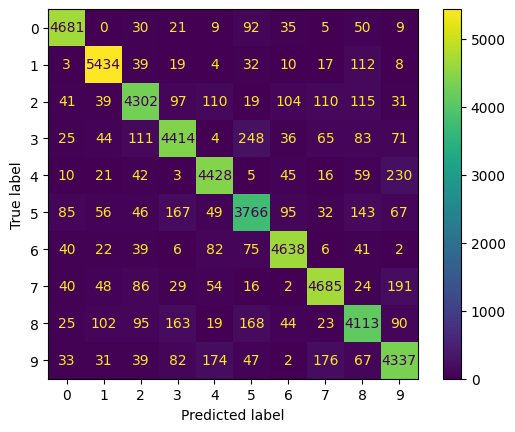

In [50]:
from sklearn.linear_model import LogisticRegression as logis
from sklearn.metrics import accuracy_score, classification_report
print("Flattening and scaling data...")
# Reshape from (N, 1, 28, 28) to (N, 784) and scale to [0, 1]
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
# Train Softmax Classifier
print("Training softmax classifier (Logistic Regression)...")
clf = logis(C=1e5, solver='lbfgs',l1_ratio=0, max_iter=200)
clf.fit(X_train_flat, y_train)

# Classify Test Set and Display Results
print("Evaluating on training set...")
y_pred = clf.predict(X_train_flat)
conf_mat = confusion_matrix(y_train, y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat)
conf_mat_disp.plot()
plt.show()




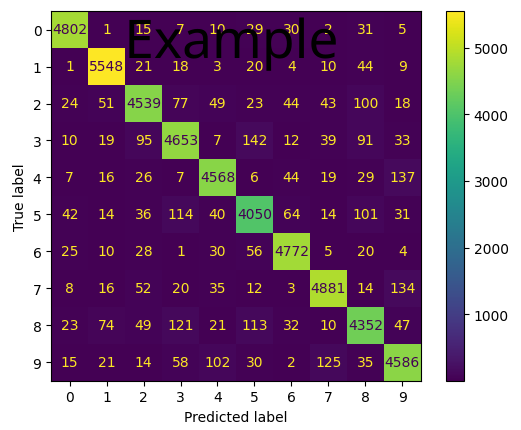

In [18]:
display(Image(filename='./images/wm_confusion2.png'))

### Accuracy

**Calculate the accuracy of your system as a fraction of the correctly classified digits. You should get something like 0.9245. use - `logis(C=1e5, solver='lbfgs', multi_class='multinomial')`**

**_Bereken nou die akkuraatheid van jou sisteem (m.a.w. watter fraksie van die syfers is reg geklassifiseer). Jy behoort min of meer 0.9245 te kry. gebruik - `logis(C=1e5, solver='lbfgs', multi_class='multinomial')`_**  


In [52]:
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0
# Classify Test Set
print("Evaluating on test set...")
y_pred_test = clf.predict(X_test_flat)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred_test)
print(f"\nTest Accuracy: {acc:.4f}")

Evaluating on test set...

Test Accuracy: 0.9027


## Extracting the weights and display as images/_Ontrek die gewigte en vertoon as beelde_

**Extract the weights of the softmax classifier and display them as images. Each set of weights should correspond to a specific digit**. 

**_Ontrek die gewigte van die softmaks klassifiseerder en vertoon as beelde. Elke stel gewigte wat vertoon kan geassosieer word met 'n spesifieke syfer._**

**As an example the weight image associated with the 0 digit should look similar to this:**

**_As 'n voorbeeld die gewigbeeld wat geassosieer word met die syfer 0 behoort soos volg te lyk:_**

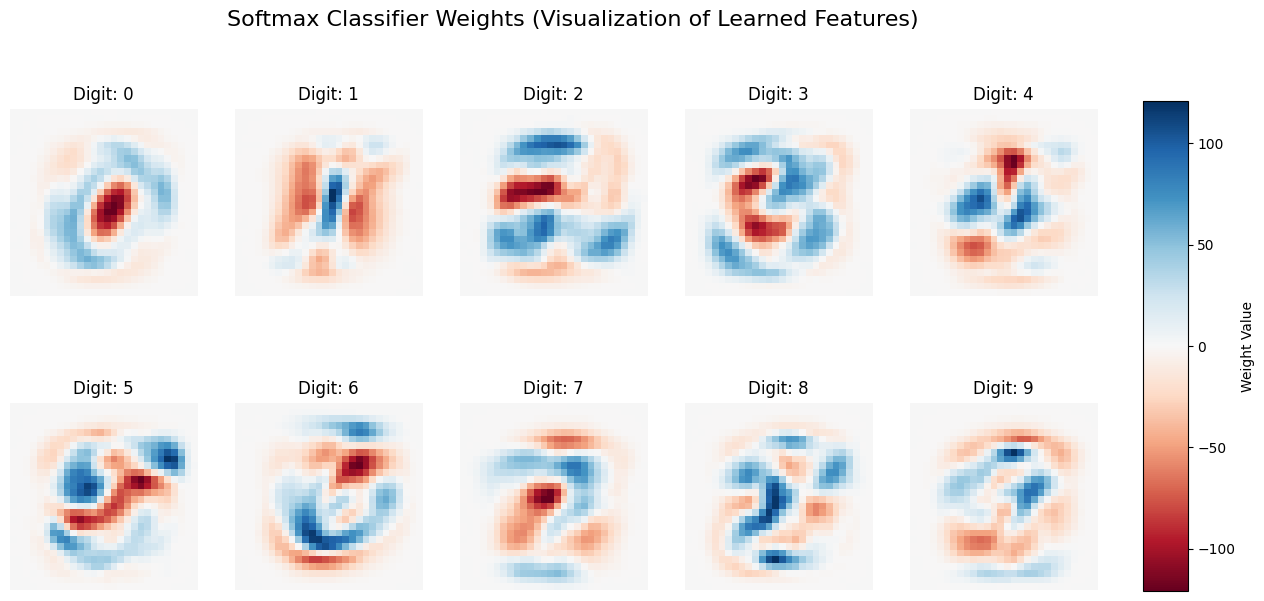

In [57]:
weights = clf.coef_.reshape(10, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Softmax Classifier Weights (Visualization of Learned Features)", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    # Calculate symmetric bounds for the colormap
    vmax = np.abs(weights[i]).max()
    
    # Plotting the weights
    im = ax.imshow(weights[i], cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f"Digit: {i}")
    ax.axis('off')

# Add a colorbar to indicate weight intensity
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Weight Value')

plt.show()

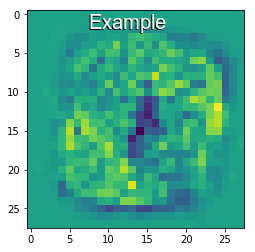

In [51]:
display(Image(filename='./wm_softmax_mnist_weights/wm_0.png'))

## Further investigation/_Verdere Ondersoek_

Fit the softmax classifier for different values of the regularization parameter - we recommend values evenly spaced on the log scale - and show the corresponding weight images for some digit as the parameter changes.  Explain the changes in the weight images observed. Moreover, plot the accuracy of your classifier as a function of the regularization parameter. Use this plot to expand on your answer.

_Pas die softmax klassifiseerder vir verskillende waardes van die regulerings konstante toe - ons stel voor om waardes te gebruik wat eweredig versprei is op die logaritmiese skaal - vertoon nou die gewigbeelde van 'n spesifieke syfer soos die parameter verander. Verduidelik die veranderinge wat jy waarneem in hierdie beelde soos die parameter verander. Stip ook die akkuraatheid van jou klassifiseerder as 'n funksie van die reguleringskonstante. Gebruik hierdie grafiek om jou vorige antwoord te staaf._